# 4. Random forest classification

Classifying patients as diabetic or not. A decision tree splits the data
repeatedly on whichever predictor yields the most information — measured here by
cross entropy — and a random forest averages many such trees, each grown on a
bootstrap resample of the rows and allowed to consider only a random subset of
the features at each split.

In [1]:
import sys
sys.path.append("..")

import numpy as np

from src.data import load_diabetes_data, prepare_diabetes_xy, diabetes_feature_names
from src.classification_metrics import accuracy, precision, f_score
from src.model_selection import make_folds, get_rng, DEFAULT_SEED
from src.plotting import metrics_table
from src.results import record_result

rng = get_rng(DEFAULT_SEED)

from src.random_forest import (
    train_forest, predict_forest, balanced_sample_weights, roc_curve,
)
from src.model_selection import grid_search_forest
from src.plotting import plot_roc, plot_precision_recall

## Loading the data

Three columns (`chol_hdl_ratio`, `bmi`, `waist_hip_ratio`) are stored with a
comma as the decimal separator, so `prepare_diabetes_xy` coerces them to floats.
Labels are encoded 0 for "No diabetes" and 1 for diabetic.

In [2]:
train_df, test_df = load_diabetes_data()
feature_names = diabetes_feature_names(train_df)

X, y = prepare_diabetes_xy(train_df, negative_label=0)
X_test, y_test = prepare_diabetes_xy(test_df, negative_label=0)

print(f"train {X.shape}, test {X_test.shape}")
print(f"frequency of positive outcomes: {y.mean():.3f}")

train (273, 13), test (117, 13)
frequency of positive outcomes: 0.161


Only about 16% of the sample is diabetic. That imbalance matters for everything
below: a model that predicted "not diabetic" for everyone would already score
roughly 84% accuracy.

## Tuning the number of trees and the maximum depth

In [3]:
folds = make_folds(len(y), 4, rng=DEFAULT_SEED)

n_trees_values = np.arange(1, 10)
depth_values = np.arange(1, 10)

best_n_trees, best_depth, best_score, grid = grid_search_forest(
    y, X, feature_names, folds, n_trees_values, depth_values, rng=rng
)

print(f"best n_trees {best_n_trees}, best max_depth {best_depth}, CV accuracy {best_score:.4f}")

best n_trees 6, best max_depth 7, CV accuracy 0.9084


In [4]:
import pandas as pd

pd.DataFrame(grid, index=[f"{n} trees" for n in n_trees_values],
             columns=[f"depth {d}" for d in depth_values]).round(3)

,depth 1,depth 2,depth 3,depth 4,depth 5,depth 6,depth 7,depth 8,depth 9
1 trees,0.839,0.842,0.828,0.813,0.831,0.839,0.864,0.831,0.875
2 trees,0.839,0.839,0.846,0.835,0.846,0.853,0.872,0.842,0.864
3 trees,0.839,0.842,0.842,0.872,0.897,0.879,0.861,0.883,0.853
4 trees,0.839,0.839,0.846,0.868,0.842,0.850,0.894,0.850,0.890
5 trees,0.839,0.839,0.835,0.846,0.875,0.857,0.894,0.846,0.868
6 trees,0.839,0.842,0.861,0.879,0.868,0.875,0.908,0.883,0.861
7 trees,0.839,0.846,0.842,0.887,0.883,0.883,0.897,0.898,0.875
8 trees,0.839,0.839,0.846,0.846,0.905,0.886,0.901,0.868,0.894
9 trees,0.839,0.887,0.850,0.875,0.861,0.879,0.886,0.865,0.879


## Unweighted forest

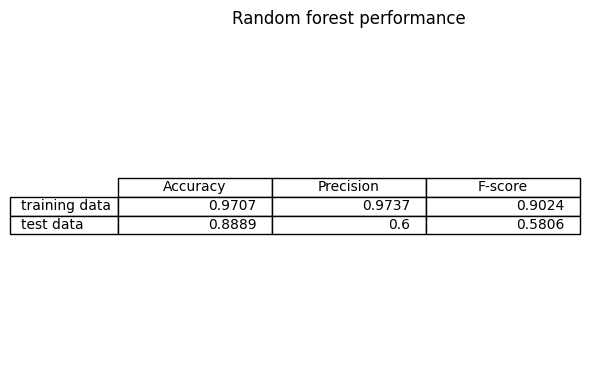

,model,split,mse,r_squared,accuracy,precision,f_score
0,Elastic net,test,1.984829,0.908297,NaN,NaN,NaN
1,Elastic net,train,1.875560,0.917734,NaN,NaN,NaN
2,Lasso,test,1.984805,0.908298,NaN,NaN,NaN
3,Lasso,train,1.875886,0.917720,NaN,NaN,NaN
4,Least squares,test,1.984390,0.908317,NaN,NaN,NaN
5,Least squares,train,1.875557,0.917734,NaN,NaN,NaN
6,Random forest,test,NaN,NaN,0.888889,0.600000,0.580645
7,Random forest,train,NaN,NaN,0.970696,0.973684,0.902439
8,kNN,test,2.985675,0.862056,NaN,NaN,NaN
9,kNN,train,2.357387,0.896600,NaN,NaN,NaN


In [5]:
forest = train_forest(X, y, feature_names, best_n_trees, best_depth, rng=rng)

y_pred = predict_forest(forest, X)
y_pred_test = predict_forest(forest, X_test)

rf_train = [accuracy(y, y_pred), precision(y, y_pred), f_score(y, y_pred)]
rf_test = [accuracy(y_test, y_pred_test), precision(y_test, y_pred_test),
           f_score(y_test, y_pred_test)]

metrics_table([rf_train, rf_test],
              columns=("Accuracy", "Precision", "F-score"),
              row_labels=("training data", "test data"),
              title="Random forest performance")

record_result("Random forest", "train", accuracy=rf_train[0], precision=rf_train[1], f_score=rf_train[2])
record_result("Random forest", "test", accuracy=rf_test[0], precision=rf_test[1], f_score=rf_test[2])

### Reading the metrics

Given what the data is for, the priority is catching as many true positives —
people who actually have diabetes — as possible. Accuracy is simply the share of
patients classified correctly either way. Precision of 0.8 would mean 80% of the
patients flagged as diabetic really are, which matters because a diabetic patient
wrongly cleared goes untreated. The F-score balances recall against precision;
some loss of precision is tolerable here, since non-diabetic patients flagged in
error can be screened out by further testing.

The training scores exceed the test scores, as expected — trees and forests
overfit readily. A wide gap despite tuned hyperparameters suggests either that
these predictors are weak indicators of diabetes, or simply that 273 training
rows is not much to learn from. The class imbalance noted above also inflates
accuracy, since predicting the majority class alone scores well on that metric.

## Weighting the classes

Inverse-frequency weights raise the influence of the minority class in both the
entropy calculation and the majority vote at each leaf.

Note this weights the *tree*, not the bootstrap: the resample itself is still
drawn uniformly, so the weights act through the split criterion rather than by
over-sampling positive cases.

In [6]:
sample_weights = balanced_sample_weights(y)
print(f"weight on a positive case: {sample_weights[y == 1][0]:.4f}")
print(f"weight on a negative case: {sample_weights[y == 0][0]:.4f}")

w_n_trees, w_depth, w_score, _ = grid_search_forest(
    y, X, feature_names, folds, n_trees_values, depth_values,
    sample_weights=sample_weights, rng=rng,
)
print(f"best n_trees {w_n_trees}, best max_depth {w_depth}, CV accuracy {w_score:.4f}")

weight on a positive case: 0.8388
weight on a negative case: 0.1612


best n_trees 7, best max_depth 7, CV accuracy 0.8939


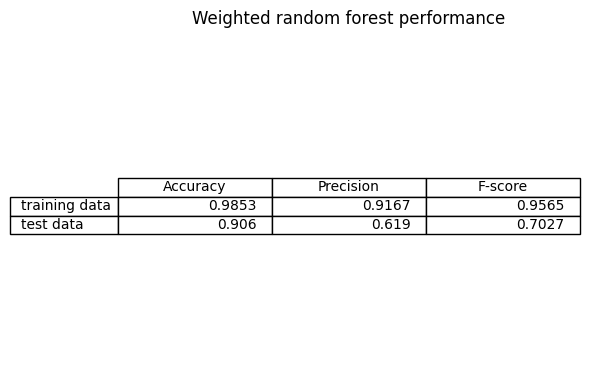

,model,split,mse,r_squared,accuracy,precision,f_score
0,Elastic net,test,1.984829,0.908297,NaN,NaN,NaN
1,Elastic net,train,1.875560,0.917734,NaN,NaN,NaN
2,Lasso,test,1.984805,0.908298,NaN,NaN,NaN
3,Lasso,train,1.875886,0.917720,NaN,NaN,NaN
4,Least squares,test,1.984390,0.908317,NaN,NaN,NaN
5,Least squares,train,1.875557,0.917734,NaN,NaN,NaN
6,Random forest,test,NaN,NaN,0.888889,0.600000,0.580645
7,Random forest,train,NaN,NaN,0.970696,0.973684,0.902439
8,Random forest (weighted),test,NaN,NaN,0.905983,0.619048,0.702703
9,Random forest (weighted),train,NaN,NaN,0.985348,0.916667,0.956522


In [7]:
weighted_forest = train_forest(
    X, y, feature_names, w_n_trees, w_depth, sample_weights, rng=rng
)

wy_pred = predict_forest(weighted_forest, X)
wy_pred_test = predict_forest(weighted_forest, X_test)

wrf_train = [accuracy(y, wy_pred), precision(y, wy_pred), f_score(y, wy_pred)]
wrf_test = [accuracy(y_test, wy_pred_test), precision(y_test, wy_pred_test),
            f_score(y_test, wy_pred_test)]

metrics_table([wrf_train, wrf_test],
              columns=("Accuracy", "Precision", "F-score"),
              row_labels=("training data", "test data"),
              title="Weighted random forest performance")

record_result("Random forest (weighted)", "train", accuracy=wrf_train[0],
              precision=wrf_train[1], f_score=wrf_train[2])
record_result("Random forest (weighted)", "test", accuracy=wrf_test[0],
              precision=wrf_test[1], f_score=wrf_test[2])

## ROC and precision-recall curves

Both curves are traced by varying the threshold applied to the fraction of trees
voting positive, from 0 through to 1.

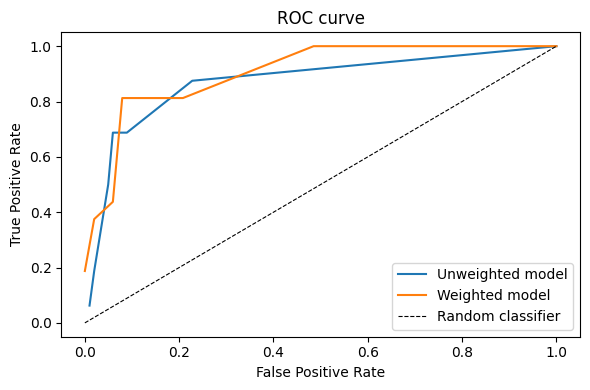

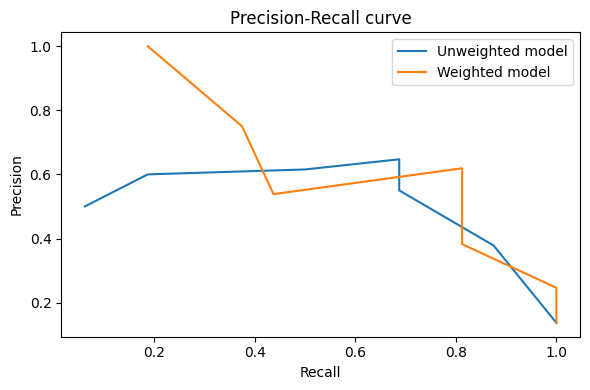

In [8]:
thresholds = np.linspace(0, 1, 21)

tpr, fpr, prec = roc_curve(forest, X_test, y_test, thresholds)
w_tpr, w_fpr, w_prec = roc_curve(weighted_forest, X_test, y_test, thresholds)

plot_roc({"Unweighted model": (fpr, tpr), "Weighted model": (w_fpr, w_tpr)})
plot_precision_recall({"Unweighted model": (tpr, prec), "Weighted model": (w_tpr, w_prec)})

## Discussion

The ROC curve measures the model's discriminative power. A useful model sits
above the `y = x` diagonal, which represents a classifier guessing at random —
anything below that line is worse than not predicting at all.

The precision-recall curve shows the trade-off directly. Choosing where on that
curve to operate is a contextual decision rather than a statistical one: a
dangerous disease warrants a threshold favouring recall, accepting more false
positives to miss fewer cases.

**Next:** [05_svm_classification.ipynb](05_svm_classification.ipynb)